In [85]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [4]:
data=pd.read_csv("/content/heart.csv")
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [37]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Reload data to ensure a clean state for encoding
# This is crucial because previous runs might have altered 'data'
data = pd.read_csv("/content/heart.csv")

le = LabelEncoder()

# Label Encode binary categorical features if they are still 'object' type
if 'Sex' in data.columns and data['Sex'].dtype == 'object':
    data['Sex'] = le.fit_transform(data['Sex'])

if 'ExerciseAngina' in data.columns and data['ExerciseAngina'].dtype == 'object':
    data['ExerciseAngina'] = le.fit_transform(data['ExerciseAngina'])

# One-Hot Encode multi-category nominal features if they are still present
cols_to_dummies = []
if 'ChestPainType' in data.columns:
    cols_to_dummies.append('ChestPainType')
if 'RestingECG' in data.columns:
    cols_to_dummies.append('RestingECG')
if 'ST_Slope' in data.columns:
    cols_to_dummies.append('ST_Slope')

if cols_to_dummies:
    data = pd.get_dummies(data, columns=cols_to_dummies, dtype=float)


In [38]:
data.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0,160,180,0,156,0,1.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,130,283,0,98,0,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,0,138,214,0,108,1,1.5,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,1,150,195,0,122,0,0.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


M=1,F=0
y=1,N=0
chestpaintype=0.0 to 1.0

In [39]:
data.shape

(918, 19)

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   Sex                918 non-null    int64  
 2   RestingBP          918 non-null    int64  
 3   Cholesterol        918 non-null    int64  
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    int64  
 6   ExerciseAngina     918 non-null    int64  
 7   Oldpeak            918 non-null    float64
 8   HeartDisease       918 non-null    int64  
 9   ChestPainType_ASY  918 non-null    float64
 10  ChestPainType_ATA  918 non-null    float64
 11  ChestPainType_NAP  918 non-null    float64
 12  ChestPainType_TA   918 non-null    float64
 13  RestingECG_LVH     918 non-null    float64
 14  RestingECG_Normal  918 non-null    float64
 15  RestingECG_ST      918 non-null    float64
 16  ST_Slope_Down      918 non

In [41]:
data.drop_duplicates(inplace=True)

In [42]:
data.isnull().sum()

,0
Age,0
Sex,0
RestingBP,0
Cholesterol,0
FastingBS,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0
HeartDisease,0
ChestPainType_ASY,0


In [43]:
data.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,132.396514,198.799564,0.233115,136.809368,0.404139,0.887364,0.553377,0.540305,0.188453,0.221133,0.050109,0.204793,0.601307,0.193900,0.068627,0.501089,0.430283
std,9.432617,0.407701,18.514154,109.384145,0.423046,25.460334,0.490992,1.066570,0.497414,0.498645,0.391287,0.415236,0.218289,0.403770,0.489896,0.395567,0.252957,0.500271,0.495386
min,28.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,138.000000,0.000000,0.600000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,60.000000,1.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [44]:
data['HeartDisease'].value_counts()


,count
HeartDisease,
1,508
0,410


In [45]:
x=data.drop(columns='HeartDisease',axis=1)
y=data['HeartDisease']

In [46]:
print(x)

     Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0     40    1        140          289          0    172               0   
1     49    0        160          180          0    156               0   
2     37    1        130          283          0     98               0   
3     48    0        138          214          0    108               1   
4     54    1        150          195          0    122               0   
..   ...  ...        ...          ...        ...    ...             ...   
913   45    1        110          264          0    132               0   
914   68    1        144          193          1    141               0   
915   57    1        130          131          0    115               1   
916   57    0        130          236          0    174               0   
917   38    1        138          175          0    173               0   

     Oldpeak  ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  \
0        0.0              

In [47]:
print(y)

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64


In [86]:
x_train,x_test,y_train,y_test,=train_test_split(x,y,test_size=0.2, stratify=y,random_state=32)

In [87]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [88]:
print(x.shape,x_train.shape,x_test.shape)

(918, 18) (734, 18) (184, 18)


Data visulalization

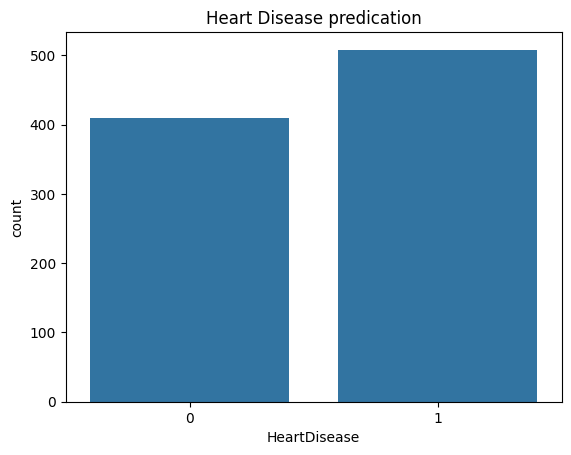

In [89]:
sns.countplot(x='HeartDisease',data=data)
plt.title("Heart Disease predication")
plt.show()

<Axes: >

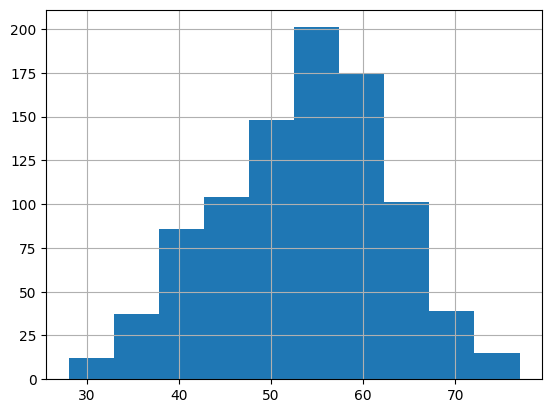

In [90]:
data['Age'].hist()

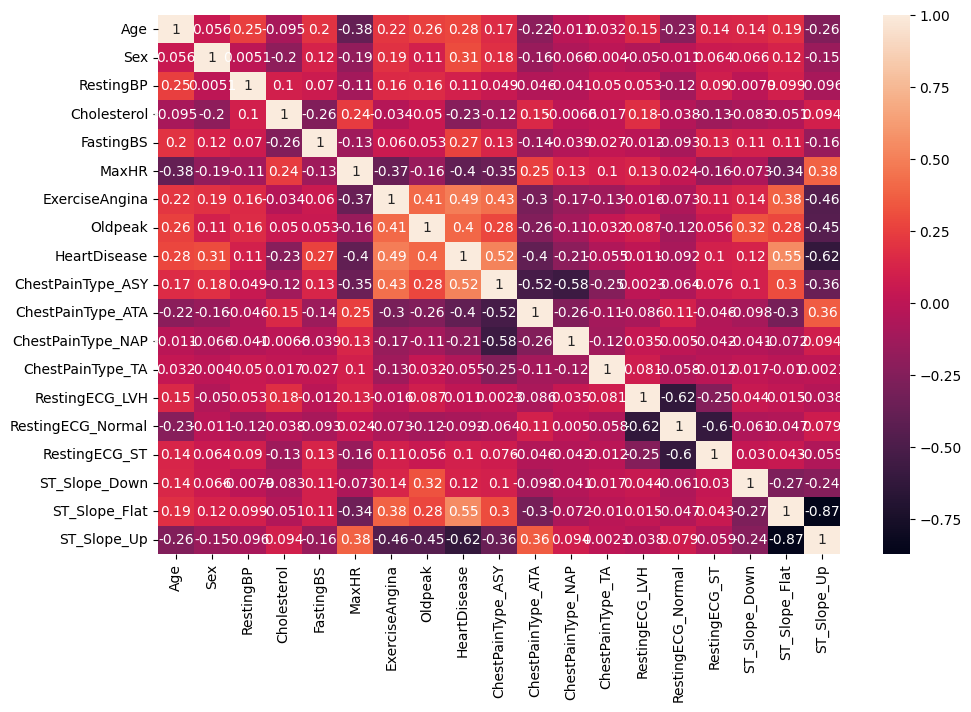

In [91]:
plt.figure(figsize=(11,7))
sns.heatmap(data.corr(),annot=True)
plt.show()

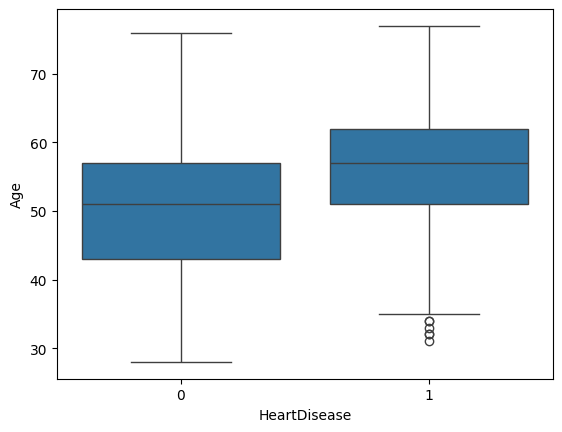

In [92]:
sns.boxplot(x='HeartDisease',y='Age',data=data)
plt.show()

Model Training


In [93]:
model1=LogisticRegression()
model1.fit(x_train,y_train)


LogisticRegression()

In [105]:
model2=RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
model2.fit(x_train,y_train)

RandomForestClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [106]:
print("Logistic Regression Accuracy:",model1.score(x_train,y_train))
print("Logistic Regression Accuracy:",model1.score(x_test,y_test))


Logistic Regression Accuracy: 0.8664850136239782
Logistic Regression Accuracy: 0.8967391304347826


In [107]:
print("Random Forest Accuracy:",model2.score(x_test,y_test))
print("Random Forest Accuracy:",model2.score(x_train,y_train))


Random Forest Accuracy: 0.8858695652173914
Random Forest Accuracy: 0.9005449591280654


In [108]:
y_pred1=model1.predict(x_test)
print("Logistic Regression Accuracy CM:\n",confusion_matrix(y_test,y_pred1))

Logistic Regression Accuracy CM:
 [[71 11]
 [ 8 94]]


In [109]:
y_pred2=model2.predict(x_test)
print("Random Forest CM:\n",confusion_matrix(y_test,y_pred2))

Random Forest CM:
 [[69 13]
 [ 8 94]]


In [110]:
print("Logistic Regression Report:\n",classification_report(y_test,y_pred1))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184



In [111]:
print("Random Forest Report:\n",classification_report(y_test,y_pred2))

Random Forest Report:
               precision    recall  f1-score   support

           0       0.90      0.84      0.87        82
           1       0.88      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

